In [1]:
#import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

PALETTE = {
    "primary":   "#1B4F72",
    "secondary": "#2E86C1",
    "accent":    "#E74C3C",
    "light":     "#AED6F1",
    "success":   "#27AE60",
    "warning":   "#F39C12",
    "bg":        "#F8F9FA",
    "text":      "#2C3E50",
}
plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"],
    "axes.facecolor":   PALETTE["bg"],
    "axes.edgecolor":   "#CCCCCC",
    "axes.labelcolor":  PALETTE["text"],
    "xtick.color":      PALETTE["text"],
    "ytick.color":      PALETTE["text"],
    "grid.color":       "#E0E0E0",
    "grid.linestyle":   "--",
    "grid.alpha":       0.7,
    "font.size":        11,
})

np.random.seed(42)

In [2]:

#Data generation

def generate_telematics_data(n=5000):
    age               = np.random.randint(18, 75, n)
    years_licensed    = np.clip(age - 17 + np.random.randint(-2, 3, n), 0, 55)
    vehicle_age       = np.random.randint(0, 20, n)
    vehicle_type      = np.random.choice(['Sedan','SUV','Truck','Sports','Hatchback'], n,
                                          p=[0.35, 0.30, 0.15, 0.10, 0.10])
    annual_mileage    = np.random.normal(12000, 4000, n).clip(1000, 40000)
    prior_claims      = np.random.poisson(0.3, n).clip(0, 5)
    avg_speed_mph           = np.random.normal(45, 12, n).clip(20, 90)
    hard_braking_per_trip   = np.random.exponential(1.5, n).clip(0, 15)
    sharp_cornering_per_trip= np.random.exponential(1.2, n).clip(0, 12)
    night_driving_pct       = np.random.beta(2, 5, n) * 100
    highway_pct             = np.random.beta(3, 3, n) * 100
    trips_per_week          = np.random.normal(25, 8, n).clip(2, 60)
    phone_use_per_trip      = np.random.exponential(0.5, n).clip(0, 6)
    speeding_pct            = np.clip(np.random.beta(1.5, 6, n) * 100, 0, 60)

    vtype_risk = {'Sedan':1.0,'Hatchback':0.9,'SUV':1.1,'Truck':1.15,'Sports':1.35}
    vtype_factor = np.array([vtype_risk[v] for v in vehicle_type])

    premium = (800
        + np.maximum(0, (25 - age)) * 20
        + np.maximum(0, (age - 65)) * 10
        - years_licensed * 8
        + vehicle_age * (-15)
        + (vehicle_age > 10) * 80
        + annual_mileage * 0.025
        + prior_claims * 180
        + avg_speed_mph * 4.5
        + hard_braking_per_trip * 55
        + sharp_cornering_per_trip * 45
        + night_driving_pct * 3.5
        - highway_pct * 1.5
        + speeding_pct * 6
        + phone_use_per_trip * 90
        + trips_per_week * 2.5
    ) * vtype_factor + np.random.normal(0, 120, n)

    premium = premium.clip(400, 8000)

    return pd.DataFrame({
        'age': age, 'years_licensed': years_licensed, 'vehicle_age': vehicle_age,
        'vehicle_type': vehicle_type, 'annual_mileage': annual_mileage.round(0).astype(int),
        'prior_claims': prior_claims, 'avg_speed_mph': avg_speed_mph.round(1),
        'hard_braking_per_trip': hard_braking_per_trip.round(2),
        'sharp_cornering_per_trip': sharp_cornering_per_trip.round(2),
        'night_driving_pct': night_driving_pct.round(1), 'highway_pct': highway_pct.round(1),
        'trips_per_week': trips_per_week.round(1), 'phone_use_per_trip': phone_use_per_trip.round(2),
        'speeding_pct': speeding_pct.round(1), 'annual_premium': premium.round(2),
    })

df = generate_telematics_data(5000)
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (5000, 15)


,age,years_licensed,vehicle_age,vehicle_type,annual_mileage,prior_claims,avg_speed_mph,hard_braking_per_trip,sharp_cornering_per_trip,night_driving_pct,highway_pct,trips_per_week,phone_use_per_trip,speeding_pct,annual_premium
0,56,37,9,SUV,11958,0,27.7,0.63,0.72,26.5,60.5,17.6,0.22,42.3,1283.39
1,69,54,1,Sports,15745,0,23.6,0.44,3.10,14.6,22.8,31.3,0.06,8.0,1568.87
2,46,28,10,Truck,14802,0,61.5,0.85,1.68,14.0,36.1,31.2,0.73,2.6,1679.68
3,32,16,9,SUV,12494,0,59.5,0.93,1.74,16.4,36.2,21.6,0.02,8.3,1306.55
4,60,45,5,Sports,7642,0,45.0,1.13,0.38,28.3,59.7,27.7,0.71,20.7,1328.00


In [3]:
print("Dataset Summary")
print(df.describe().round(2).to_string())


Dataset Summary
           age  years_licensed  vehicle_age  annual_mileage  prior_claims  avg_speed_mph  hard_braking_per_trip  sharp_cornering_per_trip  night_driving_pct  highway_pct  trips_per_week  phone_use_per_trip  speeding_pct  annual_premium
count  5000.00         5000.00      5000.00         5000.00       5000.00        5000.00                5000.00                   5000.00            5000.00      5000.00         5000.00             5000.00       5000.00         5000.00
mean     46.15           29.07         9.69        12100.07          0.29          45.11                   1.48                      1.21              28.24        50.16           25.06                0.49         19.92         1528.14
std      16.33           16.26         5.74         4026.56          0.54          11.78                   1.47                      1.24              15.80        18.83            7.99                0.48         13.49          345.24
min      18.00            0.00         0

## Exploratory Data Analysis (EDA)

### Target Variable Distribution
Understanding the shape of the premium distribution guides modeling decisions

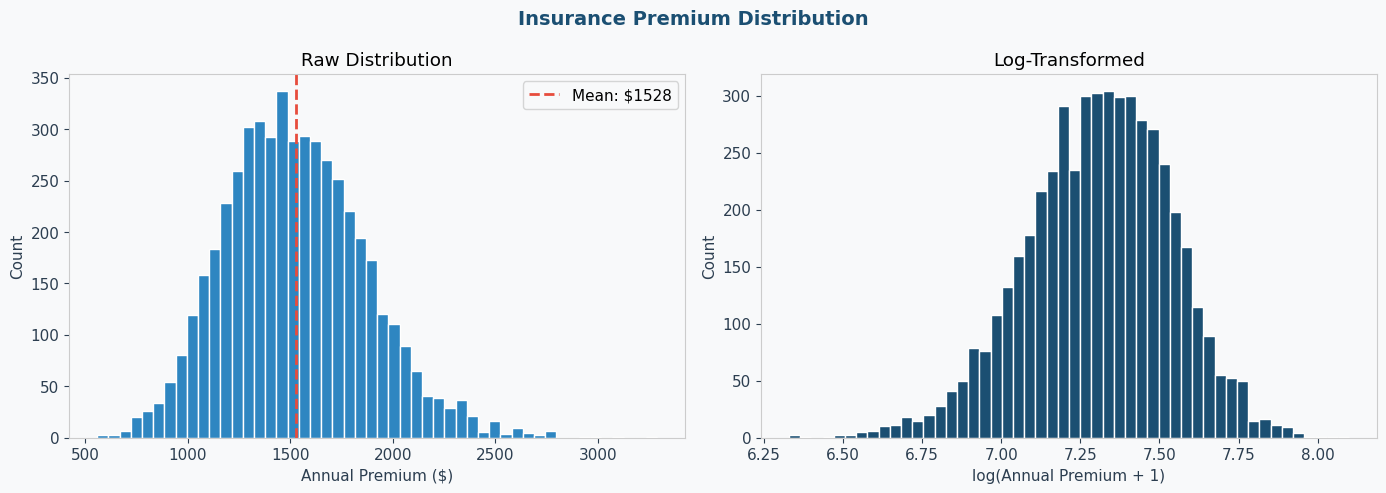

Skewness: 0.431
Kurtosis: 0.414


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Insurance Premium Distribution", fontsize=14, fontweight='bold', color=PALETTE["primary"])

axes[0].hist(df['annual_premium'], bins=50, color=PALETTE["secondary"], edgecolor='white')
axes[0].axvline(df['annual_premium'].mean(), color=PALETTE["accent"], linestyle='--', linewidth=2,
                label=f"Mean: ${df['annual_premium'].mean():.0f}")
axes[0].set_xlabel("Annual Premium ($)"); axes[0].set_ylabel("Count")
axes[0].set_title("Raw Distribution"); axes[0].legend()

axes[1].hist(np.log1p(df['annual_premium']), bins=50, color=PALETTE["primary"], edgecolor='white')
axes[1].set_xlabel("log(Annual Premium + 1)"); axes[1].set_ylabel("Count")
axes[1].set_title("Log-Transformed")

plt.tight_layout(); plt.show()
print(f"Skewness: {df['annual_premium'].skew():.3f}")
print(f"Kurtosis: {df['annual_premium'].kurtosis():.3f}")


### Feature Correlation Matrix

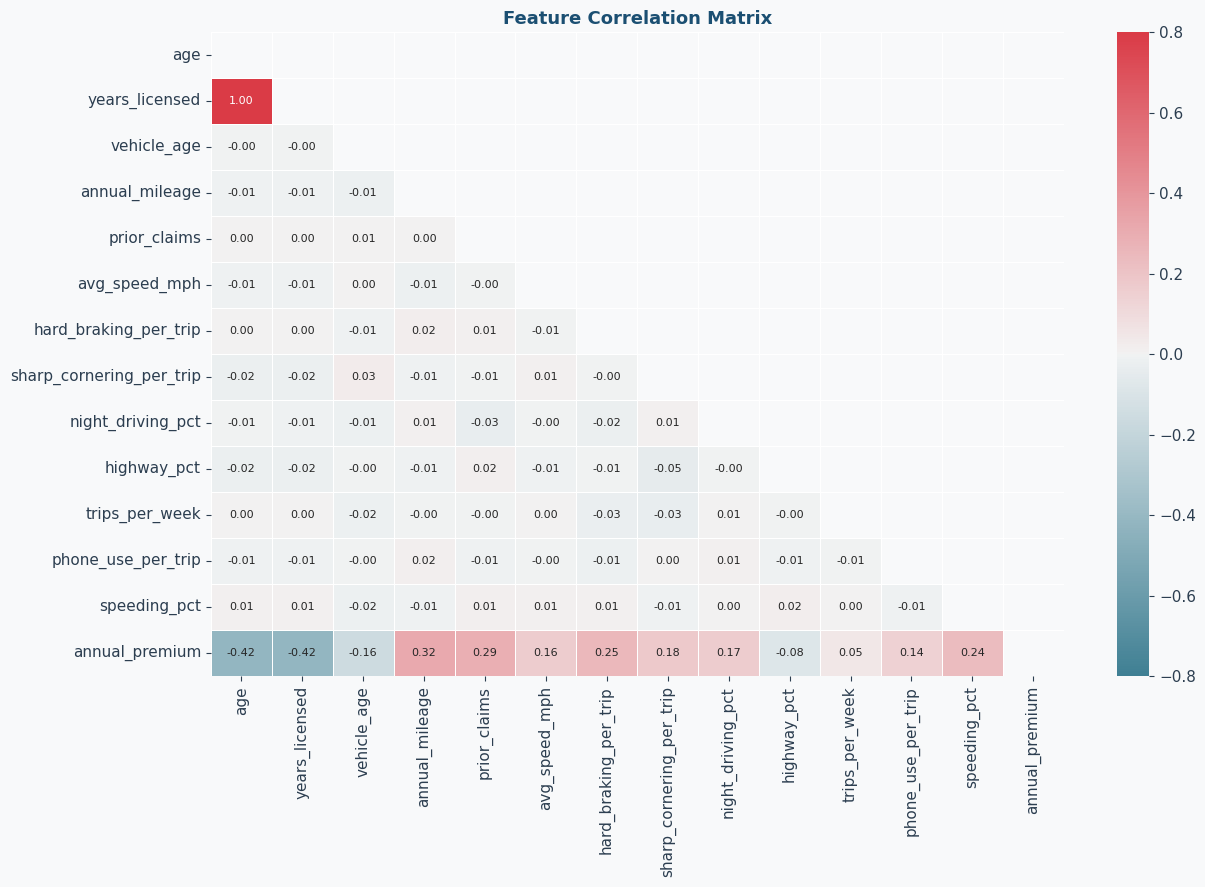


Top correlations with annual_premium:
years_licensed              0.418
age                         0.417
annual_mileage              0.317
prior_claims                0.289
hard_braking_per_trip       0.250
speeding_pct                0.236
sharp_cornering_per_trip    0.178
night_driving_pct           0.166
avg_speed_mph               0.163
vehicle_age                 0.162
phone_use_per_trip          0.138
highway_pct                 0.085
trips_per_week              0.046


In [5]:
num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(220, 10, as_cmap=True),
            vmax=0.8, vmin=-0.8, center=0, annot=True, fmt=".2f",
            linewidths=0.5, annot_kws={"size": 8}, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight='bold', color=PALETTE["primary"])
plt.tight_layout(); plt.show()

# Top correlations with premium
top_corr = corr['annual_premium'].drop('annual_premium').abs().sort_values(ascending=False)
print("\nTop correlations with annual_premium:")
print(top_corr.round(3).to_string())


### Key Telematics Signals vs Premium

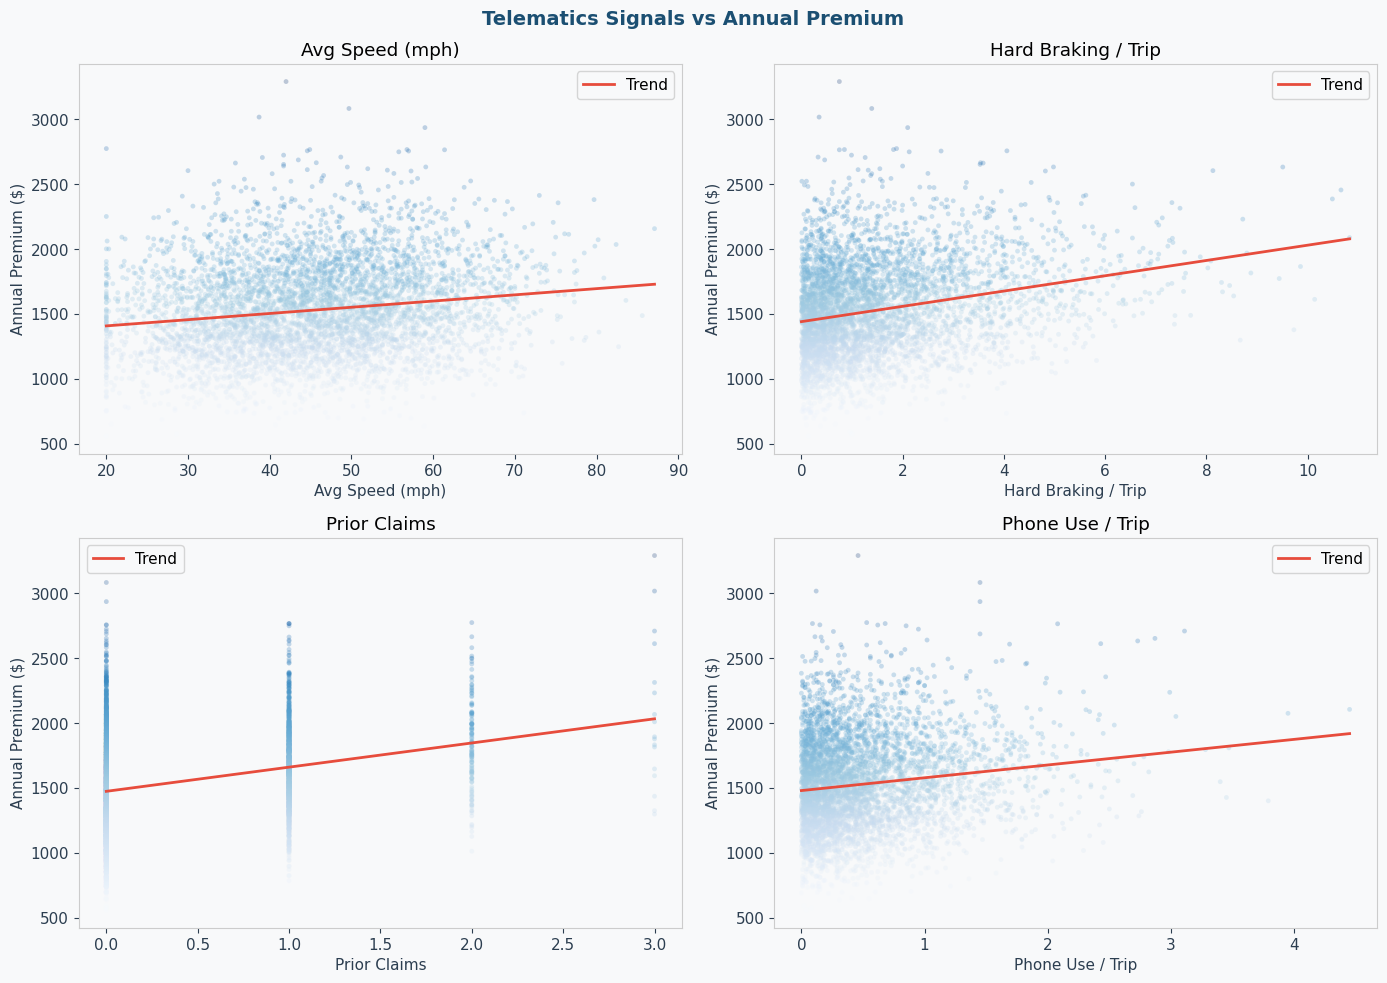

In [6]:
key_features = ['avg_speed_mph','hard_braking_per_trip','prior_claims','phone_use_per_trip']
labels = ['Avg Speed (mph)','Hard Braking / Trip','Prior Claims','Phone Use / Trip']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Telematics Signals vs Annual Premium", fontsize=14, fontweight='bold', color=PALETTE["primary"])

for ax, feat, lbl in zip(axes.flat, key_features, labels):
    ax.scatter(df[feat], df['annual_premium'], alpha=0.25, s=12,
               c=df['annual_premium'], cmap='Blues', edgecolors='none')
    z = np.polyfit(df[feat], df['annual_premium'], 1)
    xs = np.linspace(df[feat].min(), df[feat].max(), 200)
    ax.plot(xs, np.poly1d(z)(xs), color=PALETTE["accent"], linewidth=2, label="Trend")
    ax.set_xlabel(lbl); ax.set_ylabel("Annual Premium ($)"); ax.set_title(lbl); ax.legend()

plt.tight_layout(); plt.show()


### Premium by Vehicle Type

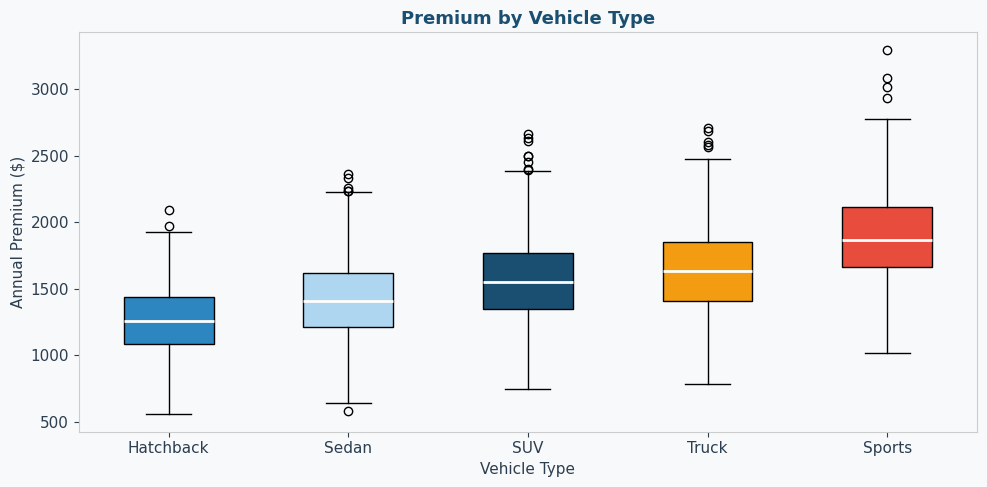

Median premiums by vehicle type:
vehicle_type
Hatchback    1254.68
Sedan        1405.03
SUV          1549.56
Truck        1628.99
Sports       1863.74
Name: annual_premium, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
vtype_order = df.groupby('vehicle_type')['annual_premium'].median().sort_values().index
colors = [PALETTE["secondary"], PALETTE["light"], PALETTE["primary"], PALETTE["warning"], PALETTE["accent"]]
bp = ax.boxplot([df[df['vehicle_type']==v]['annual_premium'] for v in vtype_order],
                labels=vtype_order, patch_artist=True,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title("Premium by Vehicle Type", fontsize=13, fontweight='bold', color=PALETTE["primary"])
ax.set_ylabel("Annual Premium ($)"); ax.set_xlabel("Vehicle Type")
plt.tight_layout(); plt.show()

print("Median premiums by vehicle type:")
print(df.groupby('vehicle_type')['annual_premium'].median().sort_values().round(2))


## Feature Engineering


In [8]:
def feature_engineering(df):
    dfe = df.copy()

    # Composite driving risk score
    dfe['driving_risk_score'] = (
        dfe['hard_braking_per_trip'] * 0.3 +
        dfe['sharp_cornering_per_trip'] * 0.2 +
        dfe['speeding_pct'] * 0.02 +
        dfe['phone_use_per_trip'] * 0.3 +
        dfe['night_driving_pct'] * 0.01
    )

    # Age bins
    dfe['age_group'] = pd.cut(dfe['age'], bins=[17,25,35,50,65,100],
                               labels=['18-25','26-35','36-50','51-65','65+'])

    # Exposure features
    dfe['mileage_per_trip']  = dfe['annual_mileage'] / (dfe['trips_per_week'] * 52 + 1)
    dfe['experience_ratio']  = dfe['years_licensed'] / (dfe['age'] - 16 + 1)

    # Encode
    le = LabelEncoder()
    dfe['vehicle_type_enc'] = le.fit_transform(dfe['vehicle_type'])
    dfe['age_group_enc']    = le.fit_transform(dfe['age_group'].astype(str))

    return dfe

dfe = feature_engineering(df)

feature_cols = [
    'age','years_licensed','vehicle_age','vehicle_type_enc','annual_mileage','prior_claims',
    'avg_speed_mph','hard_braking_per_trip','sharp_cornering_per_trip','night_driving_pct',
    'highway_pct','trips_per_week','phone_use_per_trip','speeding_pct',
    'driving_risk_score','mileage_per_trip','experience_ratio','age_group_enc',
]

X = dfe[feature_cols]
y = dfe['annual_premium']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Features: {len(feature_cols)}")
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print("\nNew engineered features:")
print(dfe[['driving_risk_score','mileage_per_trip','experience_ratio']].describe().round(3))


Features: 18
Train: 4000 | Test: 1000

New engineered features:
       driving_risk_score  mileage_per_trip  experience_ratio
count            5000.000          5000.000          5000.000
mean                1.514            10.873             0.889
std                 0.608             8.593             0.160
min                 0.263             0.560             0.000
25%                 1.077             6.789             0.880
50%                 1.430             9.250             0.933
75%                 1.860            12.719             0.974
max                 4.931           168.505             1.000


## Model Training & Evaluation

In [9]:
def eval_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f"  {name:35s} | RMSE: ${rmse:7.2f} | MAE: ${mae:7.2f} | R²: {r2:.4f}")
    return {"RMSE": rmse, "MAE": mae, "R2": r2, "y_pred": y_pred, "fitted": model}

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=10),
    "Random Forest":     RandomForestRegressor(n_estimators=150, max_depth=12,
                                               min_samples_leaf=5, n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                    learning_rate=0.08, subsample=0.8,
                                                    min_samples_leaf=5, random_state=42),
}

results = {}
print(" Model Evaluation on Test Set (n=1,000)")
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    results[name] = eval_model(mdl, X_test, y_test, name)
    results[name]["y_test"] = y_test.values

 Model Evaluation on Test Set (n=1,000)
  Linear Regression                   | RMSE: $ 191.21 | MAE: $ 153.64 | R²: 0.6927
  Ridge Regression                    | RMSE: $ 191.28 | MAE: $ 153.56 | R²: 0.6925
  Random Forest                       | RMSE: $ 173.23 | MAE: $ 134.22 | R²: 0.7478
  Gradient Boosting                   | RMSE: $ 131.45 | MAE: $ 104.20 | R²: 0.8548


### Model Comparison Visualization

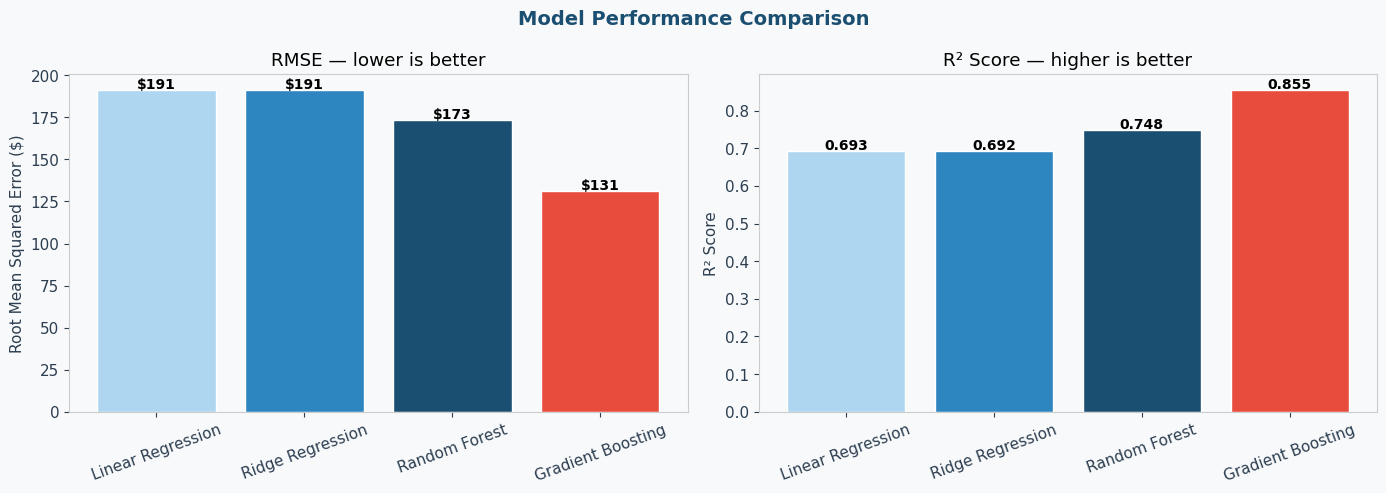

In [10]:
names     = list(results.keys())
rmse_vals = [results[n]["RMSE"] for n in names]
r2_vals   = [results[n]["R2"]   for n in names]
colors    = [PALETTE["light"], PALETTE["secondary"], PALETTE["primary"], PALETTE["accent"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Performance Comparison", fontsize=14, fontweight='bold', color=PALETTE["primary"])

for bars, vals, ax, title, ylabel in [
    (axes[0].bar(names, rmse_vals, color=colors, edgecolor='white'), rmse_vals, axes[0],
     "RMSE — lower is better", "Root Mean Squared Error ($)"),
    (axes[1].bar(names, r2_vals,   color=colors, edgecolor='white'), r2_vals,   axes[1],
     "R² Score — higher is better", "R² Score"),
]:
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        fmt = f"${val:.0f}" if ylabel.startswith("Root") else f"{val:.3f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005 * max(vals),
                fmt, ha='center', fontsize=10, fontweight='bold')

plt.tight_layout(); plt.show()


### Actual vs Predicted

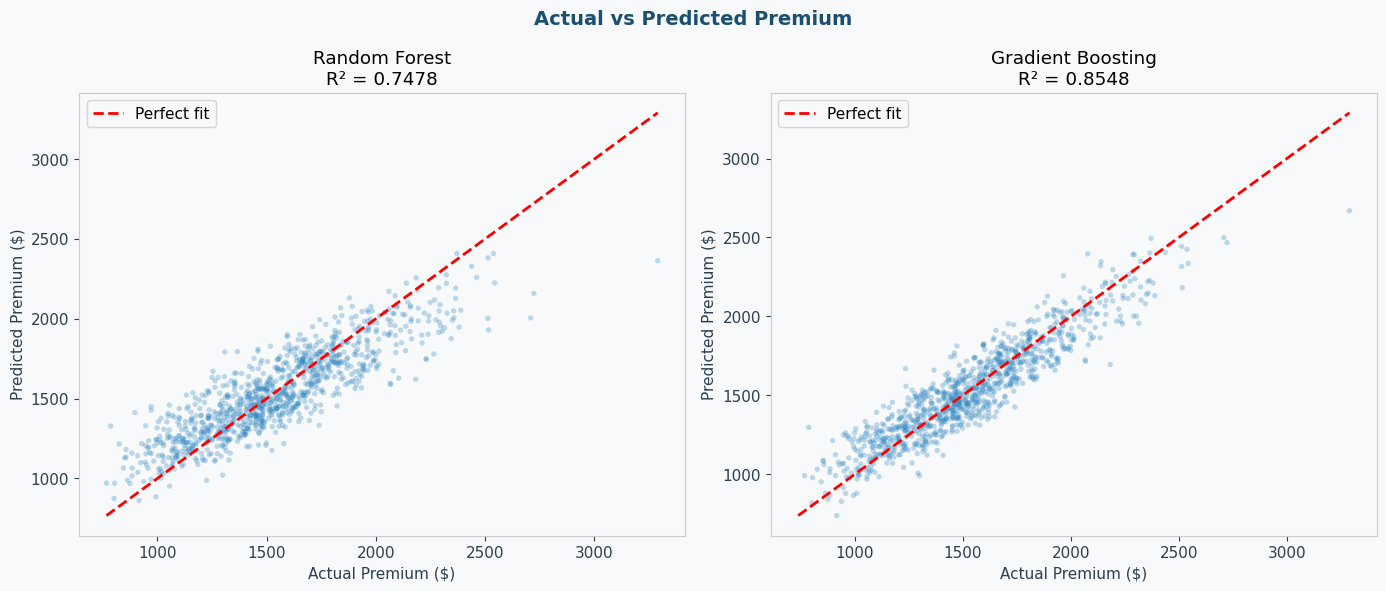

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Actual vs Predicted Premium", fontsize=14, fontweight='bold', color=PALETTE["primary"])

for ax, name in zip(axes, ["Random Forest", "Gradient Boosting"]):
    y_pred = results[name]["y_pred"]
    y_t    = results[name]["y_test"]
    ax.scatter(y_t, y_pred, alpha=0.3, s=15, color=PALETTE["secondary"], edgecolors='none')
    mn, mx = min(y_t.min(), y_pred.min()), max(y_t.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label="Perfect fit")
    ax.set_xlabel("Actual Premium ($)"); ax.set_ylabel("Predicted Premium ($)")
    ax.set_title(f"{name}\nR² = {results[name]['R2']:.4f}")
    ax.legend()

plt.tight_layout(); plt.show()


### Residual Analysis

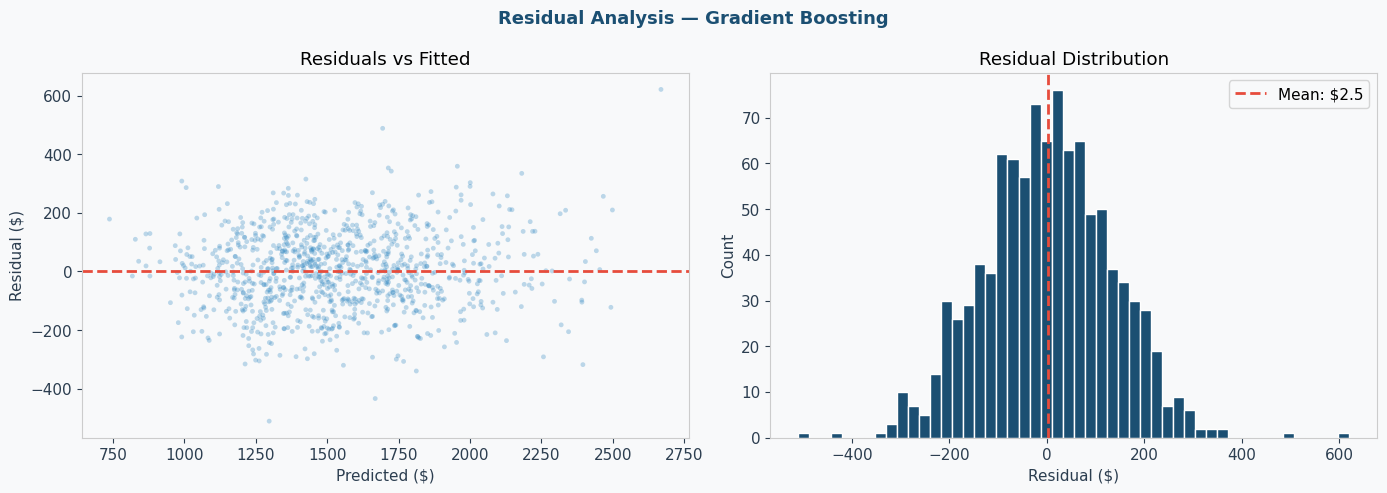

Residual std: $131.43
% within ±$100: 55.9%
% within ±$200: 86.8%


In [12]:
best = "Gradient Boosting"
y_pred = results[best]["y_pred"]
y_t    = results[best]["y_test"]
residuals = y_t - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Residual Analysis — {best}", fontsize=13, fontweight='bold', color=PALETTE["primary"])

axes[0].scatter(y_pred, residuals, alpha=0.3, s=12, color=PALETTE["secondary"], edgecolors='none')
axes[0].axhline(0, color=PALETTE["accent"], linestyle='--', linewidth=2)
axes[0].set_xlabel("Predicted ($)"); axes[0].set_ylabel("Residual ($)"); axes[0].set_title("Residuals vs Fitted")

axes[1].hist(residuals, bins=50, color=PALETTE["primary"], edgecolor='white')
axes[1].axvline(residuals.mean(), color=PALETTE["accent"], linestyle='--', linewidth=2,
                label=f"Mean: ${residuals.mean():.1f}")
axes[1].set_xlabel("Residual ($)"); axes[1].set_ylabel("Count"); axes[1].set_title("Residual Distribution")
axes[1].legend()

plt.tight_layout(); plt.show()
print(f"Residual std: ${residuals.std():.2f}")
print(f"% within ±$100: {(np.abs(residuals) <= 100).mean()*100:.1f}%")
print(f"% within ±$200: {(np.abs(residuals) <= 200).mean()*100:.1f}%")


## Feature Importance & Interpretability




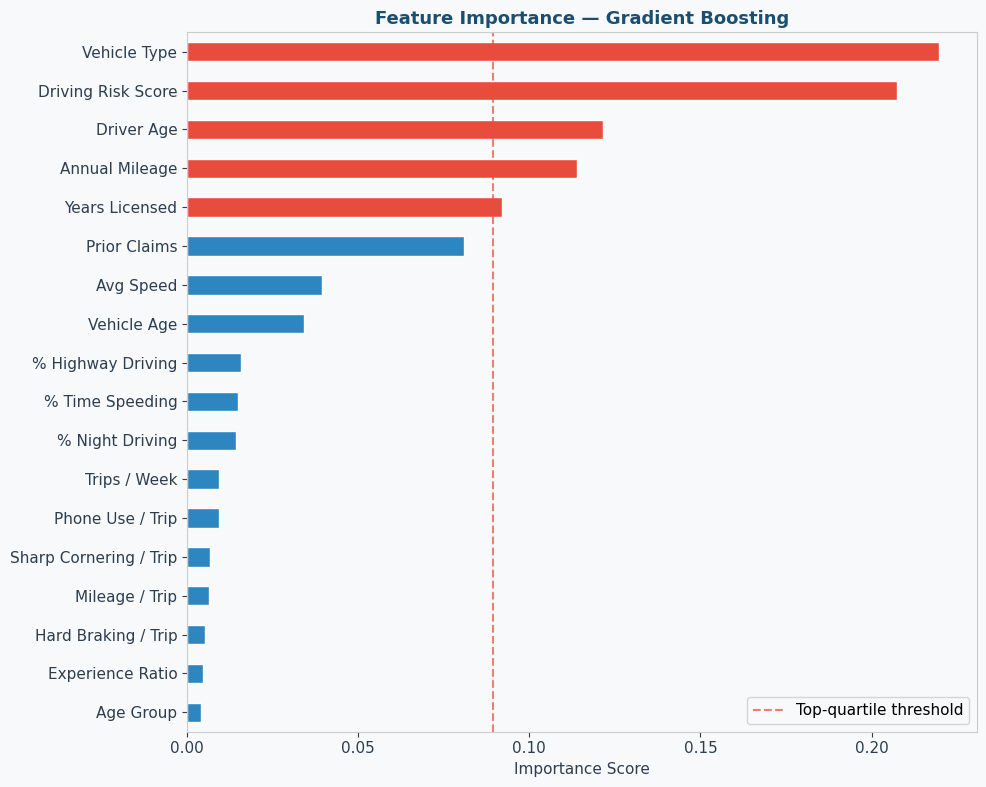


Top 5 most important features:
  Vehicle Type                  : 0.2198 (22.0%)
  Driving Risk Score            : 0.2073 (20.7%)
  Driver Age                    : 0.1215 (12.2%)
  Annual Mileage                : 0.1140 (11.4%)
  Years Licensed                : 0.0921 (9.2%)


In [13]:
name_map = {
    'avg_speed_mph':'Avg Speed','hard_braking_per_trip':'Hard Braking / Trip',
    'prior_claims':'Prior Claims','driving_risk_score':'Driving Risk Score',
    'speeding_pct':'% Time Speeding','phone_use_per_trip':'Phone Use / Trip',
    'annual_mileage':'Annual Mileage','age':'Driver Age',
    'night_driving_pct':'% Night Driving','mileage_per_trip':'Mileage / Trip',
    'sharp_cornering_per_trip':'Sharp Cornering / Trip','trips_per_week':'Trips / Week',
    'years_licensed':'Years Licensed','highway_pct':'% Highway Driving',
    'experience_ratio':'Experience Ratio','vehicle_age':'Vehicle Age',
    'vehicle_type_enc':'Vehicle Type','age_group_enc':'Age Group',
}

model = results["Gradient Boosting"]["fitted"]
fi = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
fi.index = [name_map.get(i, i) for i in fi.index]

fig, ax = plt.subplots(figsize=(10, 8))
colors = [PALETTE["accent"] if v > fi.quantile(0.75) else PALETTE["secondary"] for v in fi.values]
fi.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(fi.quantile(0.75), color=PALETTE["accent"], linestyle='--', alpha=0.7,
           linewidth=1.5, label="Top-quartile threshold")
ax.set_title("Feature Importance — Gradient Boosting", fontsize=13,
             fontweight='bold', color=PALETTE["primary"])
ax.set_xlabel("Importance Score"); ax.legend()
plt.tight_layout(); plt.show()

print("\nTop 5 most important features:")
for feat, score in fi.sort_values(ascending=False).head(5).items():
    print(f"  {feat:30s}: {score:.4f} ({score*100:.1f}%)")
